# Day 5 Sampling from Arbitrary PDFs and Maximum Likelihood

## Bicocca Lectures 4 and parts of 5

WARNING (theano.configdefaults): g++ not available, if using conda: `conda install m2w64-toolchain`
WARNING (theano.configdefaults): g++ not detected ! Theano will be unable to execute optimized C-implementations (for both CPU and GPU) and will default to Python implementations. Performance will be severely degraded. To remove this warning, set Theano flags cxx to an empty string.


WARN: Could not locate executable g77
WARN: Could not locate executable f77
WARN: Could not locate executable ifort
WARN: Could not locate executable ifl
WARN: Could not locate executable f90
WARN: Could not locate executable DF
WARN: Could not locate executable efl
WARN: Could not locate executable gfortran
WARN: Could not locate executable f95
WARN: Could not locate executable g95
WARN: Could not locate executable efort
WARN: Could not locate executable efc
WARN: Could not locate executable flang
WARN: don't know how to compile Fortran code on platform 'nt'


WARNING (theano.tensor.blas): Using NumPy C-API based implementation for BLAS functions.
C:\Users\krist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
C:\Users\krist\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\astroML\linear_model\linear_regression_errors.py:10: UserWarning: LinearRegressionwithErrors requires PyMC3 to be installed
  warnings.warn('LinearRegressionwithErrors requires PyMC3 to be installed')


@pickle_results: computing results and saving to 'fig_correlations_dump.pkl'


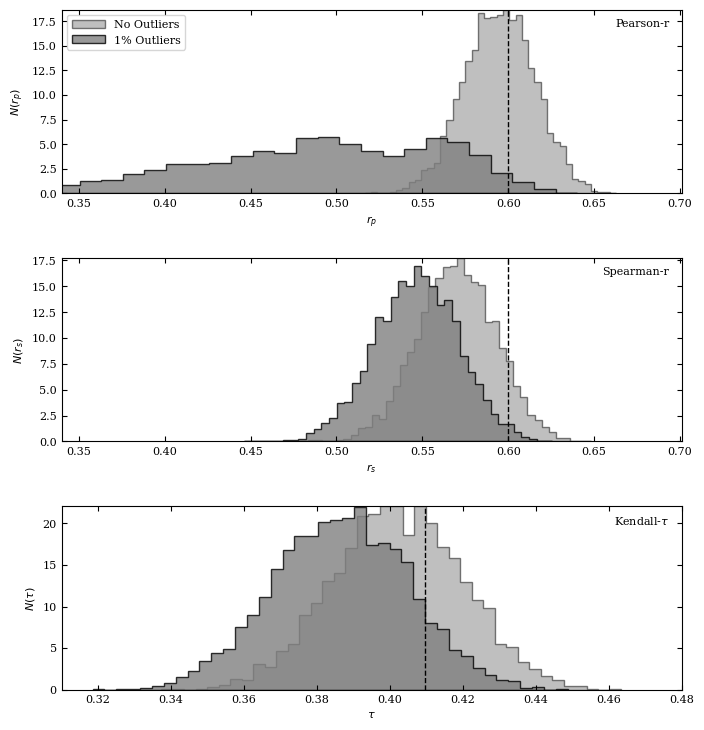

In [3]:
"""
Correlation estimates
---------------------
Figure 3.24.
Bootstrap estimates of the distribution of Pearson's, Spearman's, and Kendall's
correlation coefficients based on 2000 resamplings of the 1000 points shown
in figure 3.23. The true values are shown by the dashed lines. It is clear
that Pearson's correlation coefficient is not robust to contamination.
"""
# Author: Jake VanderPlas
# License: BSD
#   The figure produced by this code is published in the textbook
#   "Statistics, Data Mining, and Machine Learning in Astronomy" (2013)
#   For more information, see http://astroML.github.com
#   To report a bug or issue, use the following forum:
#    https://groups.google.com/forum/#!forum/astroml-general
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt

from astroML.stats.random import bivariate_normal
from astroML.utils.decorators import pickle_results

# percent sign must be escaped if usetex=True
import matplotlib
if matplotlib.rcParams.get('text.usetex'):
    pct = '\%'
else:
    pct = '%'

#----------------------------------------------------------------------
# This function adjusts matplotlib settings for a uniform feel in the textbook.
# Note that with usetex=True, fonts are rendered with LaTeX.  This may
# result in an error if LaTeX is not installed on your system.  In that case,
# you can set usetex to False.
if "setup_text_plots" not in globals():
    from astroML.plotting import setup_text_plots
setup_text_plots(fontsize=8, usetex=False)

#------------------------------------------------------------
# Set parameters for the distributions
Nbootstraps = 5000
N = 1000

sigma1 = 2.0
sigma2 = 1.0
mu = (10.0, 10.0)
alpha_deg = 45.0
alpha = alpha_deg * np.pi / 180
f = 0.01

#------------------------------------------------------------
# sample the distribution
# without outliers and with outliers
np.random.seed(0)
X = bivariate_normal(mu, sigma1, sigma2, alpha, N)

X_out = X.copy()
X_out[:int(f * N)] = bivariate_normal(mu, 2, 5,
                                      45 * np.pi / 180., int(f * N))

# true values of rho (pearson/spearman r) and tau
# tau value comes from Eq. 41 of arXiv:1011.2009
rho_true = 0.6
tau_true = 2 / np.pi * np.arcsin(rho_true)


#------------------------------------------------------------
# Create a function to compute the statistics.  Since this
#  takes a while, we'll use the "pickle_results" decorator
#  to save the results of the computation to disk
@pickle_results('fig_correlations_dump.pkl')
def compute_results(N, Nbootstraps):
    results = np.zeros((3, 2, Nbootstraps))

    for k in range(Nbootstraps):
        ind = np.random.randint(N, size=N)
        for j, data in enumerate([X, X_out]):
            x = data[ind, 0]
            y = data[ind, 1]
            for i, statistic in enumerate([stats.pearsonr,
                                           stats.spearmanr,
                                           stats.kendalltau]):
                results[i, j, k] = statistic(x, y)[0]

    return results

results = compute_results(N, Nbootstraps)

#------------------------------------------------------------
# Plot the results in a three-panel plot
fig = plt.figure(figsize=(8, 8))
fig.subplots_adjust(bottom=0.1, top=0.95, hspace=0.35)

histargs = (dict(alpha=0.5, label='No Outliers'),
            dict(alpha=0.8, label='%i%s Outliers' % (int(f * 100), pct)))

distributions = ['Pearson-r', 'Spearman-r', r'Kendall-$\tau$']
xlabels = ['r_p', 'r_s', r'\tau']\

for i in range(3):
    ax = fig.add_subplot(311 + i)
    for j in range(2):
        ax.hist(results[i, j], 40, histtype='stepfilled', fc='gray',
                density=True, **histargs[j])

    if i == 0:
        ax.legend(loc=2)

    ylim = ax.get_ylim()
    if i < 2:
        ax.plot([rho_true, rho_true], ylim, '--k', lw=1)
        ax.set_xlim(0.34, 0.701)
    else:
        ax.plot([tau_true, tau_true], ylim, '--k', lw=1)
        ax.set_xlim(0.31, 0.48)
    ax.set_ylim(ylim)

    ax.text(0.98, 0.95, distributions[i], ha='right', va='top',
            transform=ax.transAxes)

    ax.set_xlabel('$%s$' % xlabels[i])
    ax.set_ylabel('$N(%s)$' % xlabels[i])

plt.show()

### Sampling from arbitrary distributions

We often want to generate random values from a distribution which is not already included within NumPy or SciPy.

This may be an analytic function, a histogram or even a collection of observed data points.

Generating artificial samples is very useful when we want to simulate a measurement process.

These simulations are often called Monte Carlo simulations, while the artificial data may be called Monte Carlo samples or mock samples.

For example, we may want to simulate the effects of

1. Measurement uncertainty
2. Selection effects
3. Observational bias
4. Data processing
5. Survey limits

### Rejection sampling

Rejection sampling creates proposed values from a simple distribution and then decides whether to keep or reject each one.

We first choose a proposal distribution $q(x)$.

This distribution should be easy to sample from and should cover the entire range of the target distribution.

The lecture uses a uniform proposal distribution.

The general idea is

1. Generate a proposed value $x_i$
2. Generate a random vertical value $y_i$
3. Compare $y_i$ with the height of the target distribution at $x_i$
4. Accept the value if it lies below the target curve
5. Reject it if it lies above the target curve

The target distribution used in the example is

$$p(x)\propto x+\sin(x)$$

over the range $0\leq x\leq10$.

The proportional sign means that $x+\sin(x)$ gives us the shape of the distribution, but it has not been normalised yet.

For rejection sampling, we do not need the target function to be normalised. We only need to compare its height at different values of $x$.

The function is $f(x)=x+\sin(x)$.

We then generate the proposed $x$ values uniformly between $0$ and $10$. We also generate $y$ values uniformly between $0$ and a maximum height $y_{\max}$.

The point is accepted when $y<f(x)$, and rejected when otherwise.

### Why does rejection sampling work?

For a fixed value of $x$, the random $y$ value can fall anywhere between $0$ and $y_{\max}$.

The point is accepted if $y$ falls between $0$ and $f(x)$.

Therefore, the probability of accepting a particular proposed $x$ value is

$$P(\mathrm{accept}\mid x)=\frac{f(x)}{y_{\max}}$$

If the curve is tall, there is a large vertical region where the point can be accepted and vice versa.

For example, near $x=9$, the value of $f(x)$ is quite large. Most of the proposed $y$ values will fall below the curve. Near $x=1$, the value of $f(x)$ is much smaller.


The original $x$ values are proposed uniformly, but they survive with a probability proportional to $f(x)$.

Therefore, the accepted values follow $p(x)\propto f(x)$.

Once the points have been accepted, we no longer need the artificial $y$ values.

We only keep the accepted $x$ coordinates.

### Advantages and disadvantages of rejection sampling

Rejection sampling is quite simple to understand and implement.

1. It can also be used when we only know the shape of the target distribution and not its normalisation.
2. It can also be extended into multiple dimensions.

However, it may be inefficient, e.g if the proposal distribution covers a much larger region than the target distribution, most points will be rejected.


### Inverse transform sampling

Inverse transform sampling allows us to generate samples without rejecting any points.

Suppose our target probability density is $h(x)$. Its cumulative distribution function is

$$H(x)=\int_{-\infty}^{x}h(x')dx'$$

The cumulative distribution tells us the fraction of the total probability contained below $x$.

The inverse cumulative distribution is called the quantile function $H^{-1}(u)$.

The process for inverse transform sampling is

1. Calculate the CDF $H(x)$
2. Find its inverse $H^{-1}(u)$
3. Generate a uniform random number $u$ between $0$ and $1$
4. Calculate $x=H^{-1}(u)$

Therefore, $u\sim U(0,1)$ and $x=H^{-1}(u)$.

The resulting value of $x$ is a random sample from the target distribution.

### Intuition behind inverse transform sampling

The value $u$ represents a randomly selected cumulative probability.

For example, $u=0.25$ asks us to find the value of $x$ below which $25\%$ of the probability is contained.

The inverse CDF returns this value.

A uniform sample therefore chooses a random position within the total probability, rather than choosing a random position along the $x$ axis.

The inverse CDF then maps this probability into the correct value of $x$.

### Simple inverse transform example

The lecture first samples from $p(x)\propto x$ over $0\leq x\leq10$. We write $p(x)=Ax$ and normalise it using

$$\int_0^{10}Ax\,dx=1$$

This gives $A=\frac{1}{50}$, so the normalised probability density is

$$p(x)=\frac{x}{50}$$

The CDF is then

$$P(x)=\int_0^x\frac{x'}{50}dx'=\frac{x^2}{100}$$

We invert this to obtain $x=\sqrt{100P}$. Replacing $P$ with a uniform random value $u\sim U(0,1)$ gives

$$x=\sqrt{100u}$$

Each uniform value therefore produces one sample from the target distribution. For example, if $u=0.25$, then $x=5$. This does not give $x=2.5$ because $u$ represents cumulative probability rather than a fraction of the $x$ range. Since the probability density increases with $x$, the final sample contains more large values.

### Numerically inverting the CDF

Sometimes the CDF can be calculated but cannot be inverted analytically. For $p(x)\propto x+\sin(x)$ over $0\leq x\leq10$, the normalised CDF is

$$H(x)=\frac{x^2/2+1-\cos(x)}{51-\cos(10)}$$

We cannot easily rearrange $H(x)=u$ to make $x$ the subject. Instead, for each value $u\sim U(0,1)$, we numerically solve

$$H(x)-u=0$$

between $0$ and $10$. The solution gives one sample from the target distribution.

### Rejection sampling compared with inverse transform sampling

Rejection sampling generates proposed values and discards some of them, while inverse transform sampling turns every uniform random number into one target sample. Inverse transform sampling is therefore usually more efficient, but it requires us to calculate and invert the CDF. Rejection sampling is simpler when we only know the shape of the probability density and can also be extended into multiple dimensions.

### Cloning or upsampling

In real problems, we may only have observed data rather than the function which generated it. Cloning or upsampling means estimating the PDF or CDF from these observations and then generating more artificial samples using rejection sampling or inverse transform sampling.

This does not create new information. The additional values only follow our estimate of the original distribution, so they may help with simulations or testing methods but do not replace collecting more independent observations.


Lets actually put all this yappy information into practice!

This follows the lecture: Starting with rejection sampling

It says to look at how great they are because we don't need to write:

In [8]:
def f(x):
    return x**2

I messsed around with this below but change the function to what you'd like

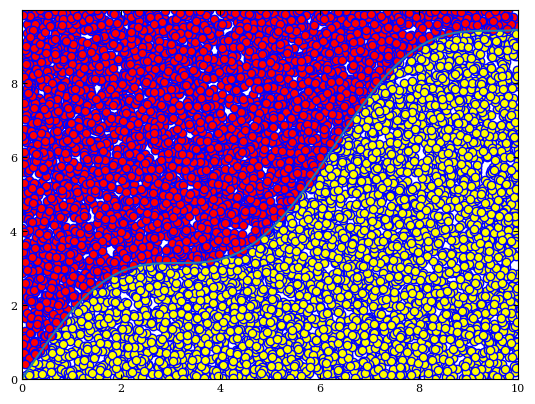

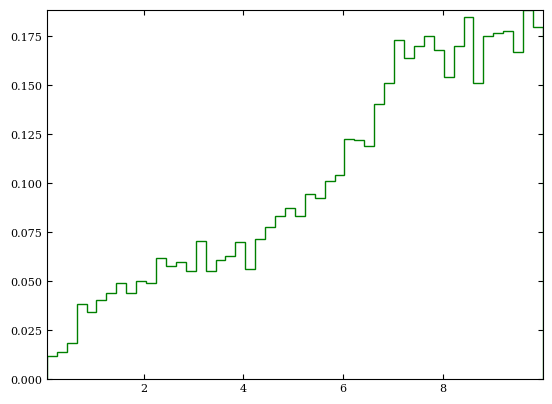

In [ ]:
f = lambda x: x+np.sin(x)  

N=10000
lam = 2
xg = np.linspace(0,10,100)

plt.plot(xg,f(xg))


ymax = 10
x = np.random.uniform(0,10,N)
y = np.random.uniform(0,ymax,N)


plt.scatter(x[y<f(x)],y[y<f(x)],c='yellow')
plt.scatter(x[y>f(x)],y[y>f(x)],c='red')

plt.show()
goodpoints = x[y<f(x)]


plt.hist(goodpoints,bins=50,density=True,histtype='step',color='green');

Now we can look at inverse sampling, this is very easy to implement:

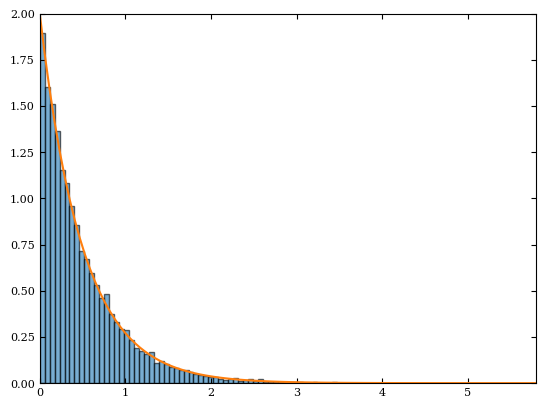

In [16]:
eps = np.random.uniform(0,1,10000)
lam = 2
x = - (1/ lam)*(np.log(eps)) # this is the inverse transformation

plt.hist(x, density=True, bins=100, alpha = 0.6);

xv=np.linspace(0,np.max(x),100)
plt.plot(xv, lam*np.exp(-lam *xv)); # Plot the actual function

## Like it says, its time get my hands dirty

We are looking at the redshift distributions of the quasars in 

I used AI here to import this 

Downloaded to: C:\Users\krist\OneDrive\Documents\GitHub\computational-astrophysics-learning\Notebooks\data\dr7qso.dat
Number of quasars loaded: 105783
Minimum redshift: 0.065
Maximum redshift: 5.461


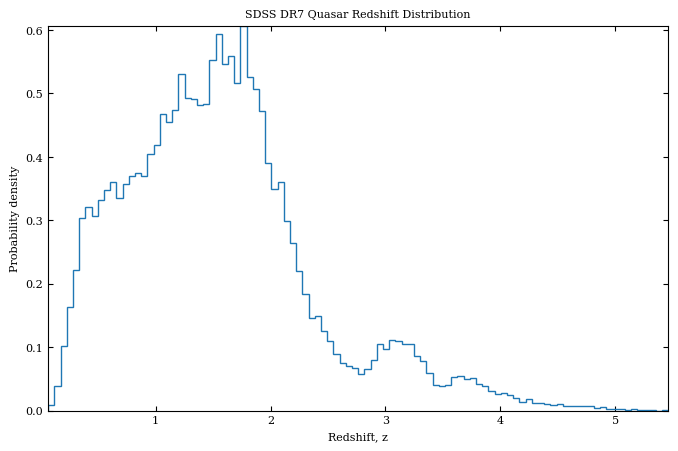

In [31]:
from pathlib import Path
from urllib.request import urlretrieve

import numpy as np
from matplotlib import pyplot as plt


# Create a data folder beside the notebook
data_directory = Path("data")
data_directory.mkdir(exist_ok=True)

# Location where the catalogue will be saved
filename = data_directory / "dr7qso.dat"

# SDSS DR7 quasar catalogue
url = "https://das.sdss.org/va/qsocat/dr7qso.dat"


# Only download the file if it is not already present
if not filename.exists():
    print("Downloading the SDSS DR7 quasar catalogue...")
    urlretrieve(url, filename)
    print(f"Downloaded to: {filename.resolve()}")
else:
    print(f"Catalogue already exists at: {filename.resolve()}")


# The file contains 80 header lines
# Column 3 contains redshift
z = np.loadtxt(
    filename,
    skiprows=80,
    usecols=3
)

# Keep only finite redshift values
z = z[np.isfinite(z)]


print(f"Number of quasars loaded: {len(z)}")
print(f"Minimum redshift: {z.min():.3f}")
print(f"Maximum redshift: {z.max():.3f}")


# Plot the observed redshift distribution
plt.figure(figsize=(8, 5))

plt.hist(
    z,
    bins=100,
    density=True,
    histtype="step"
)

plt.xlabel("Redshift, z")
plt.ylabel("Probability density")
plt.title("SDSS DR7 Quasar Redshift Distribution")

plt.show()

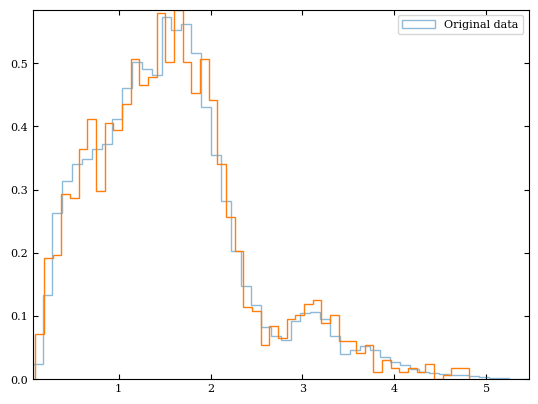

In [ ]:
from scipy.stats import gaussian_kde
plt.hist(z, bins = 50, density = True, alpha =0.5, histtype= "step", label = "Original data")
kde = gaussian_kde(z)

zmax = z.max()
zmin = z.min()
N = 10000

z_proposed = np.random.uniform(zmax,zmin, N) #often forgot to put it as random, I used linspace, very silly
y_proposed = np.random.uniform(0,1, N)

accepted = y_proposed < kde(z_proposed)

z_reject = z_proposed[accepted]

plt.hist(z_reject, bins = 50, density = True, histtype= "step")
plt.legend()


Lets now try to inverse sample this

(array([0.14073835, 0.24362293, 0.31738924, 0.34553691, 0.35330178,
        0.35136056, 0.38047884, 0.39406737, 0.47851038, 0.47365733,
        0.5115111 , 0.45618637, 0.49695196, 0.54645303, 0.55518851,
        0.54645303, 0.50568744, 0.44842149, 0.32806594, 0.27856487,
        0.19703369, 0.15432688, 0.11550251, 0.09609032, 0.0727957 ,
        0.05726595, 0.0941491 , 0.09900215, 0.10967885, 0.08929605,
        0.09511971, 0.05338351, 0.04561864, 0.04561864, 0.04464803,
        0.0417362 , 0.02814767, 0.01747097, 0.02232401, 0.01164731,
        0.01358853, 0.00582366, 0.0106767 , 0.00388244, 0.00873548,
        0.00679427, 0.00582366, 0.00388244, 0.00291183, 0.00097061]),
 array([0.11926086, 0.22228892, 0.32531699, 0.42834506, 0.53137313,
        0.6344012 , 0.73742927, 0.84045733, 0.9434854 , 1.04651347,
        1.14954154, 1.25256961, 1.35559767, 1.45862574, 1.56165381,
        1.66468188, 1.76770995, 1.87073802, 1.97376608, 2.07679415,
        2.17982222, 2.28285029, 2.38587836, 2.

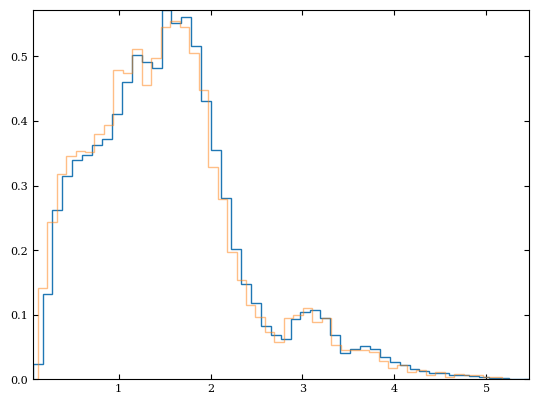

In [53]:
import scipy
plt.hist(z, bins = 50, histtype= "step", density = True)

counts, bins = np.histogram(z, bins = 50, density = True)
bin_mids = (bins[1:] + bins[:-1])/2 # this gives one middle value for each bin

simple_cdf = np.cumsum(counts) / np.sum(counts) #accumulated probability as we move from left to right

inverse_cdf = scipy.interpolate.interp1d(simple_cdf, bin_mids) #chooses from cumulative probability to give a data value

u = np.random.uniform(min(simple_cdf), max(simple_cdf), 10000)

samplex = inverse_cdf(u)

plt.hist(samplex, bins = 50, alpha = 0.5, histtype= "step", density = True)

#using density = True as they have a different number of points but we want to compare

The start of Chapter 4 and Lecture 5 has been moved to Day 6 for convenience.